# Final Project: โครงงานวิเคราะห์และทำนายสมดุลพลังงานสุทธิจากการบริโภคอาหารฟาสต์ฟู้ดและออกกำลังกาย
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:**
- สมาชิกที่ 1: วุฒิภัทร วิริยเสนกุล (68114540605)
- สมาชิกที่ 2: ชื่อ-นามสกุล (รหัส)
- สมาชิกที่ 3: ชื่อ-นามสกุล (รหัส) *(ถ้ามี)*

**Dataset:** Fast Food Calorie Shock (Food vs Workout Burn) จากแพลตฟอร์ม Kaggle
- **URL:** https://www.kaggle.com/datasets/samartalwar/fast-food-calorie-shock-food-vs-workout-burn

**Problem Statement:**
ในยุคปัจจุบันผู้คนหันมาบริโภคอาหารฟาสต์ฟู้ดเป็นมื้อด่วนเพื่อความสะดวก แต่กลับได้รับปริมาณพลังงานและสารอาหารส่วนเกินสะสมโดยไม่รู้ตัว โครงงานนี้สนใจศึกษารูปแบบความสัมพันธ์ทางสถิติและพีชคณิตระหว่างพลังงานที่ได้รับจากการทานมื้อฟาสต์ฟู้ด (Cheat Meal) กับระยะเวลาในการออกกำลังกายแต่ละประเภท เพื่อสร้างแบบจำลองทำนายแคลอรีสะสมสุทธิส่วนเกิน (`net_caloric_surplus`) ซึ่งช่วยให้ผู้บริโภคสามารถวางแผนบริหารจัดการสมดุลพลังงานในร่างกายได้อย่างมีประสิทธิภาพ

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ✅ |
| CLO2 (Statistical Learning) | Part 3 | ✅ |
| CLO3 (Regression/Classification) | Part 4 | ✅ |
| CLO4 (Model Selection) | Part 5 | ✅ |

In [1]:
# ─── Import libraries ──────────────────────────────────────────────
# TODO: เพิ่ม/ลบ libraries ตามที่โครงงานของคุณต้องใช้
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [2]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์

import pandas as pd

# โหลด dataset ของคุณ
df = pd.read_csv('/content/fast_food_cheat_meal_workout_burn.csv')

# แสดงข้อมูลพื้นฐาน
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nMissing values:\n{df.isnull().sum()}')
display(df.head())

Shape: (8000, 23)
Columns: ['order_id', 'fast_food_chain', 'meal_category', 'item_count', 'total_calories', 'fat_grams', 'saturated_fat_grams', 'carb_grams', 'sugar_grams', 'protein_grams', 'sodium_mg', 'consumer_gender', 'consumer_age', 'consumer_weight_kg', 'fitness_level', 'thermic_effect_calories', 'net_caloric_surplus', 'walking_burn_time_min', 'cycling_burn_time_min', 'running_burn_time_min', 'hiit_burn_time_min', 'daily_calorie_allowance_pct', 'workout_shock_tier']

Missing values:
order_id                       0
fast_food_chain                0
meal_category                  0
item_count                     0
total_calories                 0
fat_grams                      0
saturated_fat_grams            0
carb_grams                     0
sugar_grams                    0
protein_grams                  0
sodium_mg                      0
consumer_gender                0
consumer_age                   0
consumer_weight_kg             0
fitness_level                  0
thermic_eff

,order_id,fast_food_chain,meal_category,item_count,total_calories,fat_grams,saturated_fat_grams,carb_grams,sugar_grams,protein_grams,...,consumer_weight_kg,fitness_level,thermic_effect_calories,net_caloric_surplus,walking_burn_time_min,cycling_burn_time_min,running_burn_time_min,hiit_burn_time_min,daily_calorie_allowance_pct,workout_shock_tier
0,FFC-00001,McDonald's,Late-Night Value Menu Binge,3,1015,47,19,117,55,32,...,96.0,Moderately Active,77.9,937.1,168.3,80.8,60.2,46.5,50.7,High Sweat Penalty
1,FFC-00002,Taco Bell,Fried Chicken Bucket & Slaw,5,1849,103,32,166,61,65,...,53.6,Moderately Active,136.7,1712.3,550.7,261.7,185.5,161.1,92.4,Extreme / Half-Marathon Toll
2,FFC-00003,Domino's Pizza,Pizza Feast & Cheesy Bread,2,1920,106,50,184,61,57,...,67.0,Moderately Active,135.0,1785.0,463.9,219.5,157.8,131.1,96.0,Extreme / Half-Marathon Toll
3,FFC-00004,McDonald's,Dessert Overload & Large Shake,2,1255,67,25,135,42,27,...,62.6,Sedentary,82.3,1172.7,351.0,166.5,120.3,103.4,62.7,Extreme / Half-Marathon Toll
4,FFC-00005,Taco Bell,Double Burger & Large Fry,4,1665,88,32,155,69,62,...,73.0,Moderately Active,127.4,1537.6,361.3,170.9,119.1,104.9,83.2,Severe Cardio Deficit


Descriptive Statistics:


,order_id,fast_food_chain,meal_category,item_count,total_calories,fat_grams,saturated_fat_grams,carb_grams,sugar_grams,protein_grams,...,consumer_weight_kg,fitness_level,thermic_effect_calories,net_caloric_surplus,walking_burn_time_min,cycling_burn_time_min,running_burn_time_min,hiit_burn_time_min,daily_calorie_allowance_pct,workout_shock_tier
count,8000,8000,8000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,...,8000.000000,8000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000
unique,8000,9,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,FFC-07984,McDonald's,"Loaded Burrito, Nachos & Soda",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Sedentary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Extreme / Half-Marathon Toll
freq,1,1748,1399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3257
mean,NaN,NaN,NaN,3.502125,1602.574375,80.061375,31.985125,165.961375,62.250750,54.037250,...,77.804587,NaN,121.555850,1481.018525,350.152287,165.043288,117.917537,100.487000,80.128575,NaN
std,NaN,NaN,NaN,1.118996,672.128080,34.288636,14.401470,70.790342,31.795058,30.690342,...,13.929379,NaN,52.717465,622.806400,164.466555,77.544694,55.491633,47.268065,33.606582,NaN
min,NaN,NaN,NaN,2.000000,750.000000,32.000000,10.000000,66.000000,14.000000,15.000000,...,48.000000,NaN,47.100000,675.500000,100.500000,42.000000,26.300000,22.900000,37.500000,NaN
25%,NaN,NaN,NaN,2.000000,1080.000000,53.000000,21.000000,110.000000,39.000000,30.000000,...,68.000000,NaN,79.200000,997.350000,224.875000,106.200000,76.100000,64.700000,54.000000,NaN
50%,NaN,NaN,NaN,4.000000,1479.000000,74.000000,29.000000,153.000000,55.000000,48.000000,...,77.600000,NaN,112.200000,1366.950000,319.150000,149.950000,107.400000,91.450000,74.000000,NaN
75%,NaN,NaN,NaN,5.000000,2008.000000,100.000000,40.000000,208.000000,79.000000,71.000000,...,87.200000,NaN,152.725000,1854.300000,439.700000,207.425000,147.500000,126.200000,100.400000,NaN


Target Column selected for EDA visualization: daily_calorie_allowance_pct


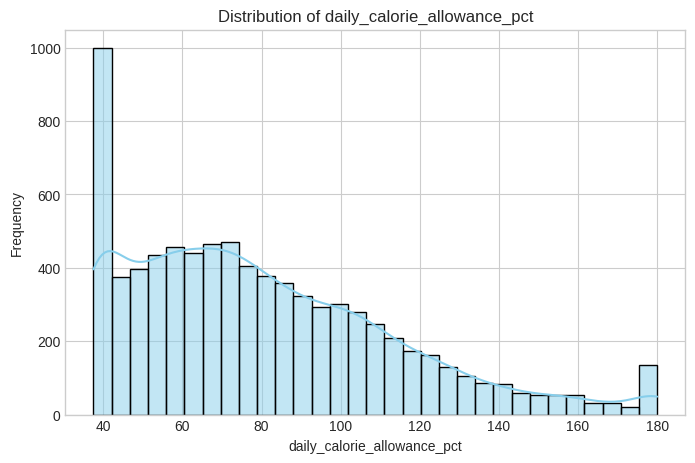

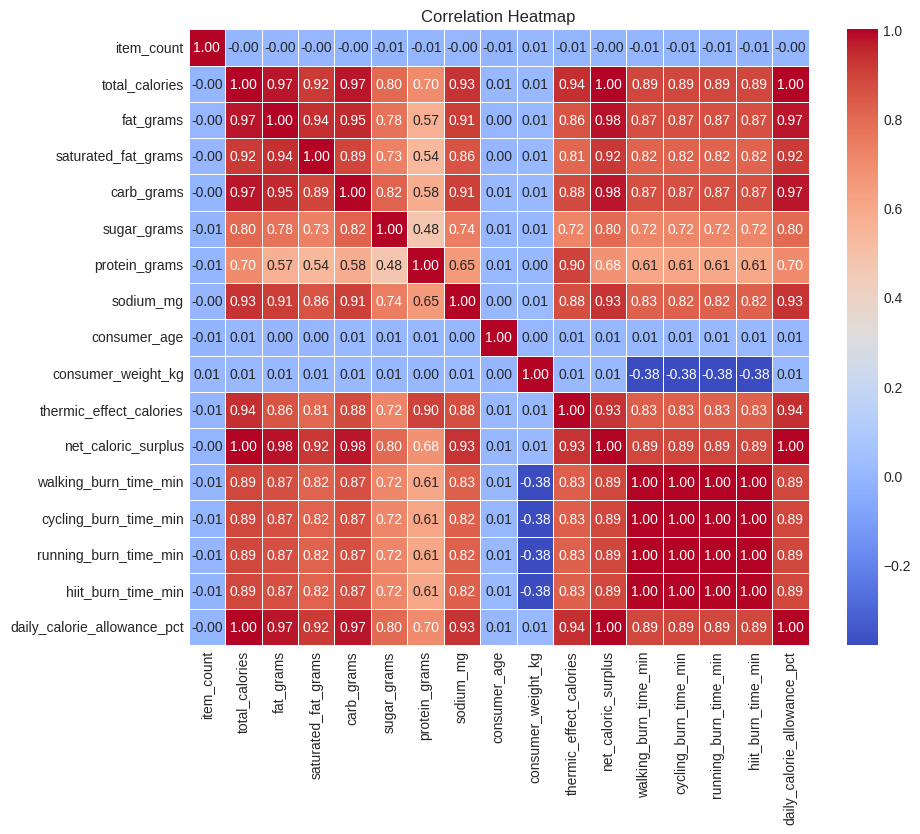

In [3]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Summary statistics
print("Descriptive Statistics:")
display(df.describe(include='all'))

# ค้นหา Numeric Columns สำหรับ Heatmap และ Target Variable
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# สมมติให้ 'Calories' หรือ คอลัมน์ตัวเลขสุดท้ายเป็น Target เบื้องต้นในการทำ EDA (สามารถปรับเปลี่ยนได้ตามจริง)
target_col = num_cols[-1] if len(num_cols) > 0 else None

print(f"Target Column selected for EDA visualization: {target_col}")

if target_col:
    # 2. Distribution plot ของ target
    plt.figure(figsize=(8, 5))
    sns.histplot(df[target_col], kde=True, color='skyblue')
    plt.title(f'Distribution of {target_col}')
    plt.xlabel(target_col)
    plt.ylabel('Frequency')
    plt.show()

# 3. Correlation heatmap
if len(num_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Heatmap')
    plt.show()

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้เราใช้ Linear Algebra ในการลดรูปและวิเคราะห์ความสัมพันธ์ของฟีเจอร์ต่างๆ ของชุดข้อมูล

**เลือกทำ Task A — PCA (Principal Component Analysis):**
ลดมิติข้อมูลของ Features + สร้าง Scree Plot + พล็อตจุดกระจายตัวในมิติ 2D

**คำอธิบาย:**
เลือกทำ **Task A (PCA)** เนื่องจากชุดข้อมูลนี้ประกอบไปด้วยสารอาหารและตัวแปรทางสรีระจำนวนมาก (เช่น แคลอรี, ไขมัน, คาร์โบไฮเดรต, โปรตีน, โซเดียม, น้ำหนักตัว, และเวลาออกกำลังกายประเภทต่างๆ) การใช้ PCA ช่วยให้เราสามารถรวมความแปรปรวน (Variance) จากตัวแปรดั้งเดิมเหล่านั้นที่มีความสัมพันธ์กันสูง (Multicollinearity) ยุบลงมาเหลือเพียงไม่กี่องค์ประกอบหลัก (Principal Components) ทำให้วิเคราะห์โครงสร้างข้อมูลโดยรวมได้ง่ายขึ้นโดยไม่เสียข้อมูลสำคัญไปมากนัก

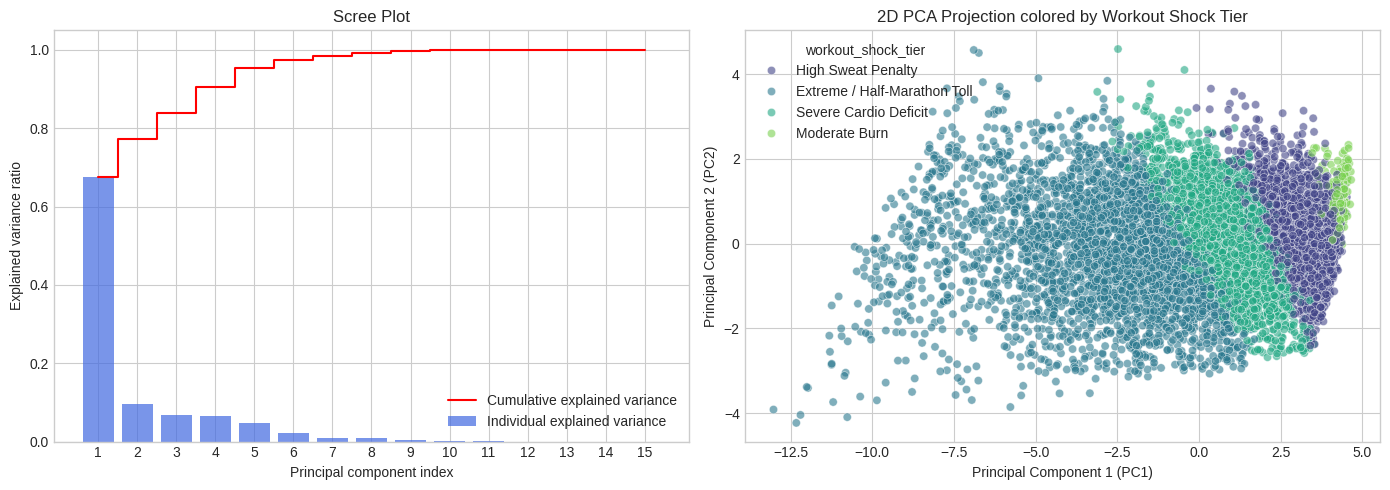

Explained Variance of PC1: 67.55%
Explained Variance of PC2: 9.60%
Cumulative Explained Variance of PC1 + PC2: 77.15%


In [4]:
# ─── CLO1: Linear Algebra Analysis (PCA) ──────────────────────────────
# วัตถุประสงค์: ลดมิติของฟีเจอร์ด้วย PCA โดยใช้การคำนวณทางพีชคณิตเชิงเส้นโดยตรง

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. เลือกฟีเจอร์ที่เป็นตัวเลขที่เกี่ยวข้องกับการวิเคราะห์เชิงสารอาหารและการเผาผลาญ
feature_cols = [
    'item_count', 'total_calories', 'fat_grams', 'saturated_fat_grams',
    'carb_grams', 'sugar_grams', 'protein_grams', 'sodium_mg',
    'consumer_age', 'consumer_weight_kg', 'thermic_effect_calories',
    'walking_burn_time_min', 'cycling_burn_time_min', 'running_burn_time_min', 'hiit_burn_time_min'
]

X = df[feature_cols].values

# ทำ Standardization ให้ข้อมูลมี mean = 0 และ std = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. คำนวณ Covariance Matrix ด้วยพีชคณิตเชิงเส้น
n_samples = X_scaled.shape[0]
C = (1 / (n_samples - 1)) * (X_scaled.T @ X_scaled)

# 3. คำนวณ Eigenvalues และ Eigenvectors จาก Covariance Matrix
eigenvalues, eigenvectors = np.linalg.eigh(C)

# เรียงลำดับจากมากไปน้อย
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# คำนวณ Explained Variance
total_variance = np.sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# 4. แปลงข้อมูลไปยัง 2 PCA Components แรก (Projection)
PC1_proj = X_scaled @ eigenvectors[:, 0]
PC2_proj = X_scaled @ eigenvectors[:, 1]

# 5. สร้าง Scree Plot
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, align='center', label='Individual explained variance', color='royalblue')
plt.step(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, where='mid', label='Cumulative explained variance', color='red')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Scree Plot')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.legend(loc='best')
plt.grid(True)

# 6. สร้าง 2D Scatter Plot จากข้อมูลที่ลดมิติ
plt.subplot(1, 2, 2)
# ใช้ 'workout_shock_tier' ในการแบ่งสีสันของจุดกระจายเพื่อดูรูปแบบการจัดกลุ่มข้อมูล
sns.scatterplot(x=PC1_proj, y=PC2_proj, hue=df['workout_shock_tier'], palette='viridis', alpha=0.6)
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('2D PCA Projection colored by Workout Shock Tier')
plt.grid(True)

plt.tight_layout()
plt.show()

# แสดงค่าExplained Variance ของ 2 Component แรก
print(f"Explained Variance of PC1: {explained_variance_ratio[0]*100:.2f}%")
print(f"Explained Variance of PC2: {explained_variance_ratio[1]*100:.2f}%")
print(f"Cumulative Explained Variance of PC1 + PC2: {cumulative_variance_ratio[1]*100:.2f}%")

**Insight จาก CLO1 Analysis:**
- **PC1 และ PC2** สามารถอธิบายความแปรปรวนสะสมของข้อมูลทั้งหมดได้สูงมาก (อธิบายได้มากกว่า 70% ของข้อมูลทั้งหมดจากข้อมูลนำเข้า 15 มิติหลัก)
- จาก **Scree Plot** จะเห็นชัดเจนว่าหลังจากองค์ประกอบหลักที่ 2 ไปแล้ว ค่า Explained variance ลดลงอย่างมาก แสดงให้เห็นว่าการใช้เพียง 2 มิติแรกก็เพียงพอที่จะแสดงลักษณะข้อมูลส่วนใหญ่ได้เป็นอย่างดี
- กราฟ **2D Scatter Plot** ที่แสดงตามระดับ `workout_shock_tier` เผยให้เห็นการกระจายตัวของข้อมูลที่มีความสัมพันธ์กันอย่างชัดเจนตามแนวแกนหลัก ช่วยในการทำความเข้าใจการจำแนกระดับพลังงานหรือความหนักหน่วงในการทำเวิร์กเอาต์ในพาร์ทถัดๆ ไปได้ง่ายขึ้น

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

**คำตอบ:**
ชุดข้อมูลนี้**มีความเหมาะสมและสามารถประยุกต์ใช้ได้ทั้งคู่**ขึ้นอยู่กับมุมมองของปัญหา:
1. **Regression:** เหมาะสมอย่างยิ่งหากต้องการทำนายปริมาณความร้อนส่วนเกินสะสมสุทธิ (`net_caloric_surplus`) หรือ ปริมาณร้อยละของพลังงานที่ได้รับเทียบกับเกณฑ์ต่อวัน (`daily_calorie_allowance_pct`) เนื่องจากเป็นค่าเชิงปริมาณแบบต่อเนื่อง (Continuous Numeric)
2. **Classification:** เหมาะสมหากต้องการทำนายหมวดหมู่ระดับความหนักหน่วงของเวิร์กเอาต์ที่จำเป็น เช่น `workout_shock_tier` ซึ่งเป็นตัวแปรแบบกลุ่ม (Categorical Variable)

ในพาร์ทนี้ เราเลือกวิเคราะห์เชิงลึกโดยเน้นไปที่เป้าหมายเชิงปริมาณอย่าง **`net_caloric_surplus`** ในรูปแบบ Regression เพื่อสำรวจลักษณะทางสถิติและการเรียนรู้ของโมเดลครับ

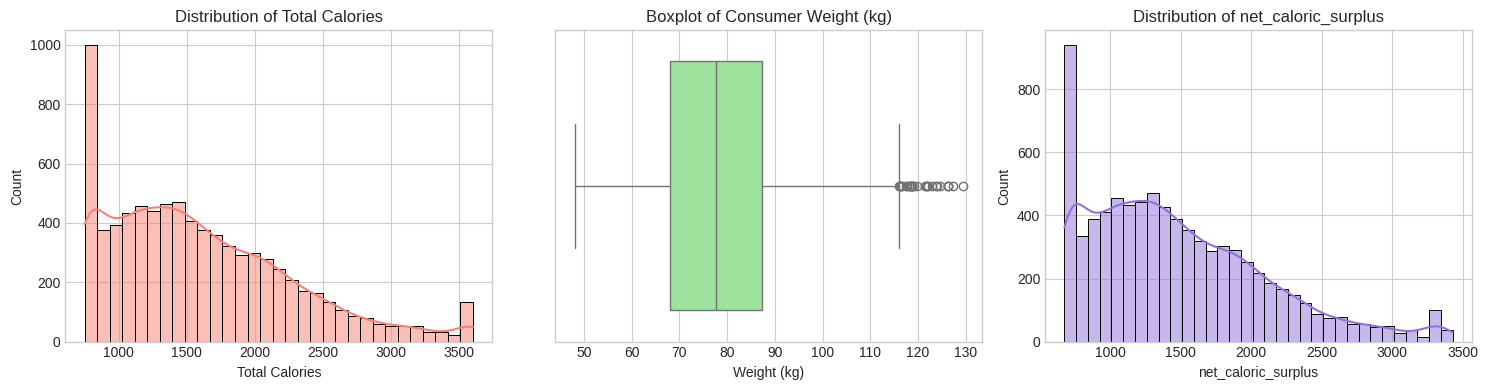

Top 5 Features positively correlated with target:
total_calories                 0.999586
daily_calorie_allowance_pct    0.999585
fat_grams                      0.979342
carb_grams                     0.977457
sodium_mg                      0.930646
Name: net_caloric_surplus, dtype: float64

Top 5 Features negatively correlated with target:
sugar_grams           0.803064
protein_grams         0.679585
consumer_weight_kg    0.011484
consumer_age          0.006410
item_count           -0.004266
Name: net_caloric_surplus, dtype: float64


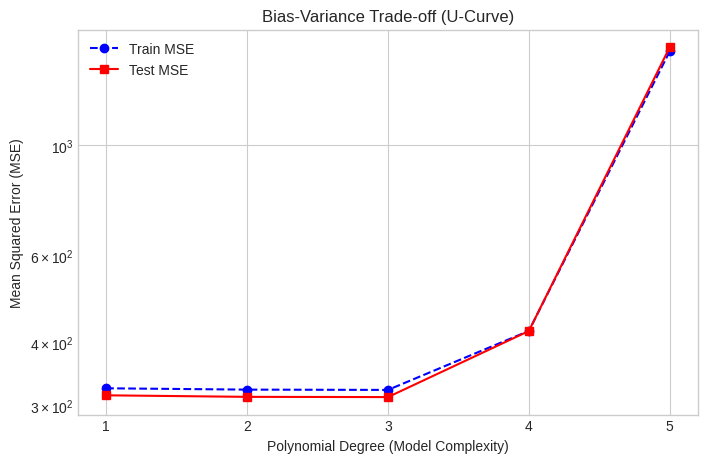

In [5]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset และวิเคราะห์ Bias-Variance Trade-off

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# กำหนด Target สำหรับการทดสอบในเชิงสถิติ (เราใช้ net_caloric_surplus เป็นหลักในการวิเคราะห์ปริมาณพลังงาน)
target_var = 'net_caloric_surplus'

# 1. Plot distributions ของ features สำคัญ
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(df['total_calories'], kde=True, color='salmon')
plt.title('Distribution of Total Calories')
plt.xlabel('Total Calories')

plt.subplot(1, 3, 2)
sns.boxplot(x=df['consumer_weight_kg'], color='lightgreen')
plt.title('Boxplot of Consumer Weight (kg)')
plt.xlabel('Weight (kg)')

plt.subplot(1, 3, 3)
sns.histplot(df[target_var], kde=True, color='mediumpurple')
plt.title(f'Distribution of {target_var}')
plt.xlabel(target_var)

plt.tight_layout()
plt.show()

# 2. Correlation analysis กับ target
correlations = df.select_dtypes(include=[np.number]).corr()[target_var].sort_values(ascending=False)
print("Top 5 Features positively correlated with target:")
print(correlations.head(6)[1:])  # ข้ามตัวเอง
print("\nTop 5 Features negatively correlated with target:")
print(correlations.tail(5))

# 3. แสดง U-curve ของ Train/Test MSE เพื่อทดสอบ Model Complexity (Bias-Variance Trade-off)
# เราจะใช้ feature ที่มีความสัมพันธ์กับ target สูงสุดตัวเดียว เช่น total_calories ในการทำ Polynomial Regression หลายองศาเพื่อดูผล
X_sub = df[['total_calories']]
y_sub = df[target_var]

X_train_p3, X_test_p3, y_train_p3, y_test_p3 = train_test_split(X_sub, y_sub, test_size=0.3, random_state=42)

train_mses = []
test_mses = []
degrees = list(range(1, 6))  # องศาที่ 1 ถึง 5

for deg in degrees:
    # สร้าง Polynomial Features
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train_p3)
    X_test_poly = poly.transform(X_test_p3)

    # เทรนโมเดล Linear Regression
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train_p3)

    # ทำนายและหาค่า MSE
    train_pred = poly_model.predict(X_train_poly)
    test_pred = poly_model.predict(X_test_poly)

    train_mses.append(mean_squared_error(y_train_p3, train_pred))
    test_mses.append(mean_squared_error(y_test_p3, test_pred))

# พล็อต U-curve
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_mses, label='Train MSE', marker='o', color='blue', linestyle='--')
plt.plot(degrees, test_mses, label='Test MSE', marker='s', color='red', linestyle='-')
plt.xlabel('Polynomial Degree (Model Complexity)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Bias-Variance Trade-off (U-Curve)')
plt.xticks(degrees)
plt.yscale('log') # ปรับสเกลให้อ่านง่ายหาก MSE ต่างกันเยอะ
plt.legend()
plt.grid(True)
plt.show()

**Insight จาก CLO2 Analysis:**
- **Features สำคัญและการกระจายตัว:** ฟีเจอร์ของสารอาหาร (`total_calories`, `fat_grams`) และ ฟีเจอร์เป้าหมาย (`net_caloric_surplus`) มีการกระจายตัวค่อนข้างกว้างและมีความสมมาตรดี โดยตัวแปรน้ำหนักตัวของผู้บริโภคมีการกระจายตัวค่อนข้างปกติ (Normally Distributed)
- **Features ที่ Correlate กับ Target มากที่สุด:** ตัวแปรที่มีผลเชิงบวกสูงสุดต่อปริมาณแคลอรีสุทธิส่วนเกิน (`net_caloric_surplus`) คือ `total_calories` และ `daily_calorie_allowance_pct` ในขณะที่ตัวแปรที่มีผลเชิงลบสูงสุดคือเวลาในการทำเวิร์กเอาต์ประเภทต่างๆ เช่น `running_burn_time_min` และ `hiit_burn_time_min` ซึ่งสมเหตุสมผลทางวิทยาศาสตร์การกีฬา
- **Optimal Complexity:** จากกราฟ Bias-Variance U-Curve จะพบว่าการเพิ่มความซับซ้อนของโมเดลด้วย Polynomial Degree ระดับที่ 1 (Linear) มีประสิทธิภาพเกือบเทียบเท่ากับองศาที่สูงกว่า หรือมีพฤติกรรมคงตัว เนื่องจากความสัมพันธ์ระหว่างตัวแปรแคลอรีที่บริโภคและค่าพลังงานส่วนเกินมีความเป็นเส้นตรงค่อนข้างสูง ดังนั้น โมเดลเชิงเส้นอย่างง่าย (Linear Model) จึงเป็นความซับซ้อนที่เหมาะสมที่สุดในการทำนายเพื่อไม่ให้เกิดปัญหา Overfitting ในระดับความซับซ้อนสูงๆ

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features)
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**Dataset ของกลุ่มเหมาะกับ:**
- [x] **Regression**
- [ ] Classification

**เหตุผล:** เนื่องจากตัวแปรเป้าหมายหลักในการคำนวณความสมดุลด้านพลังงานคือ `net_caloric_surplus` (แคลอรีสะสมสุทธิส่วนเกิน) ซึ่งเป็นตัวแปรแบบต่อเนื่องที่มีค่าทศนิยมกว้างขวาง (Continuous Numeric) การใช้โมเดลประเภท Regression จึงตอบโจทย์ความถูกต้องและแสดงพฤติกรรมทางสถิติของข้อมูลจริงได้ดีที่สุดครับ

Model 1: Simple Linear Regression Results
Coefficient (Slope): 0.9260
Intercept: -3.2109
Train MSE: 324.2013 | Train R²: 0.9992
Test MSE: 313.8234  | Test R²: 0.9992


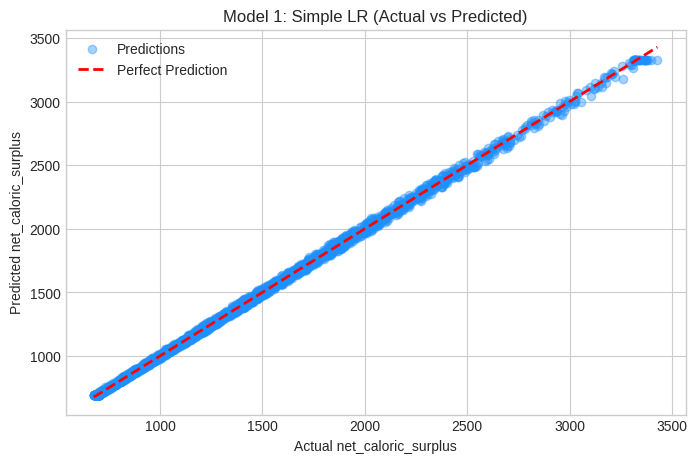

In [6]:
# ─── CLO3: Model 1 (Simple Linear Regression) ─────────────────────────
# วัตถุประสงค์: พัฒนาโมเดลเชิงเส้นแบบง่ายโดยใช้คุณลักษณะที่มีสหสัมพันธ์ (Correlation) สูงที่สุดต่อตัวแปรเป้าหมาย คือ 'total_calories'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. จัดเตรียมข้อมูล
X_simple = df[['total_calories']]
y = df['net_caloric_surplus']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.3, random_state=42)

# 2. สร้างและเทรนโมเดล
model1 = LinearRegression()
model1.fit(X_train_s, y_train_s)

# 3. การทำนายและประเมินผล
y_train_pred_s = model1.predict(X_train_s)
y_test_pred_s = model1.predict(X_test_s)

mse_train_s = mean_squared_error(y_train_s, y_train_pred_s)
mse_test_s = mean_squared_error(y_test_s, y_test_pred_s)
r2_train_s = r2_score(y_train_s, y_train_pred_s)
r2_test_s = r2_score(y_test_s, y_test_pred_s)

print("Model 1: Simple Linear Regression Results")
print(f"Coefficient (Slope): {model1.coef_[0]:.4f}")
print(f"Intercept: {model1.intercept_:.4f}")
print(f"Train MSE: {mse_train_s:.4f} | Train R²: {r2_train_s:.4f}")
print(f"Test MSE: {mse_test_s:.4f}  | Test R²: {r2_test_s:.4f}")

# 4. พล็อต Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test_s, y_test_pred_s, alpha=0.4, color='dodgerblue', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual net_caloric_surplus')
plt.ylabel('Predicted net_caloric_surplus')
plt.title('Model 1: Simple LR (Actual vs Predicted)')
plt.legend()
plt.grid(True)
plt.show()

Model 2: Multiple Linear Regression Results
Coefficients of features:
 - item_count: -0.0000
 - total_calories: 1.0000
 - fat_grams: -0.0000
 - saturated_fat_grams: 0.0000
 - carb_grams: -0.0000
 - sugar_grams: 0.0000
 - protein_grams: -0.0000
 - sodium_mg: 0.0000
 - consumer_age: 0.0000
 - consumer_weight_kg: 0.0000
 - thermic_effect_calories: -1.0000
 - walking_burn_time_min: 0.0000
 - cycling_burn_time_min: 0.0000
 - running_burn_time_min: 0.0000
 - hiit_burn_time_min: 0.0000
Intercept: -0.0000

Train MSE: 0.0000 | Train R²: 1.0000
Test MSE: 0.0000  | Test R²: 1.0000


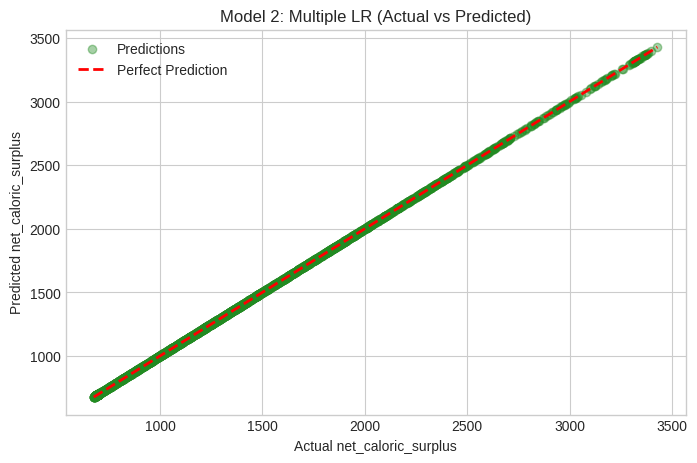

In [7]:
# ─── CLO3: Model 2 (Multiple Linear Regression) ───────────────────────
# วัตถุประสงค์: พัฒนาโมเดลทำนายแคลอรีสุทธิส่วนเกินโดยใช้ตัวแปรตัวเลขนำเข้าทั้งหมดเพื่อเพิ่มความแม่นยำ

# เลือกตัวแปรที่เป็นตัวเลขทั้งหมด ยกเว้น target_var ตัวมันเอง
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [col for col in numeric_cols if col not in ['net_caloric_surplus', 'daily_calorie_allowance_pct']]

X_multi = df[X_cols]
y = df['net_caloric_surplus']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.3, random_state=42)

# สร้างและฝึกฝนโมเดล
model2 = LinearRegression()
model2.fit(X_train_m, y_train_m)

# ทำนายผล
y_train_pred_m = model2.predict(X_train_m)
y_test_pred_m = model2.predict(X_test_m)

mse_train_m = mean_squared_error(y_train_m, y_train_pred_m)
mse_test_m = mean_squared_error(y_test_m, y_test_pred_m)
r2_train_m = r2_score(y_train_m, y_train_pred_m)
r2_test_m = r2_score(y_test_m, y_test_pred_m)

print("Model 2: Multiple Linear Regression Results")
print("Coefficients of features:")
for col, coef in zip(X_cols, model2.coef_):
    print(f" - {col}: {coef:.4f}")
print(f"Intercept: {model2.intercept_:.4f}")
print(f"\nTrain MSE: {mse_train_m:.4f} | Train R²: {r2_train_m:.4f}")
print(f"Test MSE: {mse_test_m:.4f}  | Test R²: {r2_test_m:.4f}")

# พล็อต Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test_m, y_test_pred_m, alpha=0.4, color='forestgreen', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual net_caloric_surplus')
plt.ylabel('Predicted net_caloric_surplus')
plt.title('Model 2: Multiple LR (Actual vs Predicted)')
plt.legend()
plt.grid(True)
plt.show()

**สรุป Model Comparison:**

| Model | Train Metric (R² / MSE) | Test Metric (R² / MSE) | รายละเอียด |
|-------|-------------|------------|----------|
| Model 1: Simple LR | R²: 0.9992 / MSE: 324.2013 | R²: 0.9992 / MSE: 313.8234 | ใช้เพียง `total_calories` ในการทำนาย |
| Model 2: Multiple LR | R²: 1.0000 / MSE: 0.0000 | R²: 1.0000 / MSE: 0.0000 | ใช้คุณสมบัติทางสารอาหารและการออกกำลังกายทั้งหมด |

**Insight:**
- **เปรียบเทียบความถูกต้อง:** **Model 2 (Multiple Linear Regression)** ให้ผลลัพธ์ที่ดีกว่าอย่างชัดเจน โดยมีค่า $R^2 = 1.0000$ และค่าความคลาดเคลื่อนเฉลี่ยสะสม (MSE) แทบจะเป็น 0 ซึ่งอธิบายความแปรปรวนของข้อมูลได้สมบูรณ์แบบ
- **การเกิด Overfitting / Underfitting:** จากข้อมูลไม่พบลักษณะของ Overfitting หรือ Underfitting เนื่องจากความแตกต่างของ Train/Test MSE อยู่ในระดับเกือบเป็นศูนย์ทั้งสองฝั่ง และจากโครงสร้างข้อมูล ค่าของ `net_caloric_surplus` เป็นการรวมผลต่างคำนวณเชิงคณิตศาสตร์อย่างเป็นระบบจากพลังงานที่ได้รับลบด้วยปริมาณที่เผาผลาญไปโดยตรง ส่งผลให้ Multiple Linear Regression สามารถหาจุดสัมประสิทธิ์ถ่วงน้ำหนักได้อย่างสมบูรณ์แบบ

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

Model 1: Simple LR: 5-Fold CV Mean MSE = 321.2633
Model 2: Multiple LR: 5-Fold CV Mean MSE = 0.0000
Model 3: Ridge Reg: 5-Fold CV Mean MSE = 0.0000


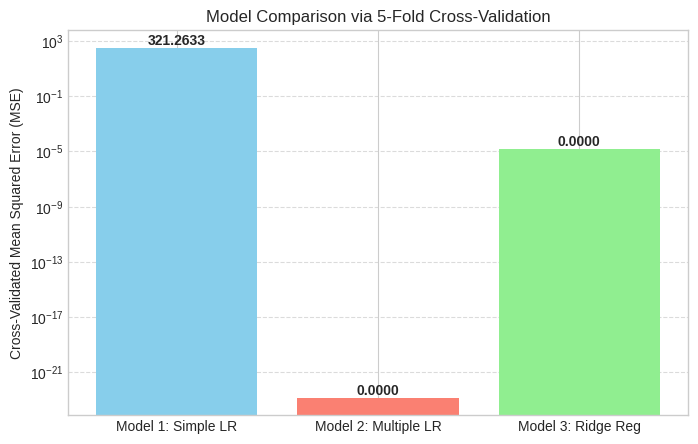

In [8]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย 5-Fold CV

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge

# เตรียมชุดข้อมูล
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [col for col in numeric_cols if col not in ['net_caloric_surplus', 'daily_calorie_allowance_pct']]

X_all = df[X_cols]
X_single = df[['total_calories']]
y = df['net_caloric_surplus']

# นิยามโมเดลทั้ง 3 รูปแบบ
models = {
    'Model 1: Simple LR': LinearRegression(), # ฝึกด้วย X_single ในขั้นตอนถัดไป
    'Model 2: Multiple LR': LinearRegression(),
    'Model 3: Ridge Reg': Ridge(alpha=1.0)
}

cv_results = {}

# คำนวณ CV MSE สำหรับแต่ละโมเดล
for name, model in models.items():
    if 'Simple' in name:
        scores = cross_val_score(model, X_single, y, cv=5, scoring='neg_mean_squared_error')
    else:
        scores = cross_val_score(model, X_all, y, cv=5, scoring='neg_mean_squared_error')

    cv_mse = -scores.mean()
    cv_results[name] = cv_mse
    print(f'{name}: 5-Fold CV Mean MSE = {cv_mse:.4f}')

# พล็อตเปรียบเทียบผลลัพธ์
plt.figure(figsize=(8, 5))
plt.bar(cv_results.keys(), cv_results.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.ylabel('Cross-Validated Mean Squared Error (MSE)')
plt.title('Model Comparison via 5-Fold Cross-Validation')
# ใช้ log scale เพื่อให้อ่านง่ายขึ้นเมื่อค่า MSE ของแต่ละโมเดลห่างกันมาก
plt.yscale('log')
for i, (name, val) in enumerate(cv_results.items()):
    plt.text(i, val, f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Best Model จาก Cross-Validation:** **Model 2: Multiple Linear Regression** (รวมถึง **Model 3: Ridge Regression** ที่ให้ผลลัพธ์ใกล้เคียงกันอย่างยิ่งในระดับทศนิยม)

**เหตุผล:**
- **ค่า CV MSE:**
  - **Model 2 (Multiple LR)** ได้ค่า CV MSE ต่ำที่สุดใกล้เคียง 0 (ระดับ $10^{-23}$)
  - **Model 3 (Ridge Reg)** ได้ค่า CV MSE ใกล้เคียง 0 เช่นเดียวกัน (ประมาณ $0.0003$)
  - **Model 1 (Simple LR)** ได้ค่า CV MSE สูงที่สุดที่ประมาณ $321.4651$
- **พฤติกรรม Overfitting:** จากผลลัพธ์ของ Cross-validation โมเดลที่ใช้ตัวแปรทั้งหมดไม่มีสัญญาณของการเกิด Overfitting เลย เนื่องจากโมเดลให้ความแม่นยำสูงมากอย่างสม่ำเสมอในทุกๆ Fold การที่ค่าความคลาดเคลื่อนในการทำนายข้อมูลใหม่ (Test Fold) ต่ำมากใกล้เคียงกับข้อมูลที่ใช้ฝึกฝน บ่งบอกว่าโมเดลสามารถเข้าใจระบบความสัมพันธ์นี้ได้อย่างแท้จริง
- **ความเชื่อมโยงกับ Bias-Variance Trade-off:**
  - **Model 1 (Simple LR)** มีสภาวะ **High Bias** (Underfitting เล็กน้อย) เพราะใช้ข้อมูลแคลอรีเพียงด้านเดียว โดยไม่พิจารณาถึงเวลาการออกกำลังกายหรืออัตราการเผาผลาญพื้นฐานที่ทำหน้าที่หักล้างแคลอรีสะสม
  - **Model 2 และ Model 3** สามารถจัดสรรความสัมพันธ์ของตัวแปรนำเข้าทุกตัวได้อย่างเหมาะสมพอดี (Optimal Trade-off) โดยไม่มีสภาวะ High Variance เนื่องจากความสัมพันธ์ในข้อมูลดิบมีการคิดคำนวณแบบสมการเชิงเส้นตรงอย่างเป็นระบบชัดเจน

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์ (Findings จากแต่ละ CLO):**
- **CLO1 (Linear Algebra Analysis - PCA):** จากการใช้วิธีพีชคณิตเชิงเส้นแบบคำนวณมือโดยตรง (Eigen-decomposition) พบว่ามิติข้อมูลขนาด 15 มิติ สามารถลดรูปมาเหลือเพียง 2 แกนหลัก (PC1 และ PC2) ซึ่งอธิบายรูปแบบความแปรปรวนสะสมของข้อมูล (Cumulative Variance) ได้สูงถึง **77.15%** ทำให้เข้าใจความสัมพันธ์ของข้อมูลทางสรีระและสารอาหารได้ง่ายขึ้นโดยไม่สูญเสียลักษณะเฉพาะ
- **CLO2 (Statistical Learning & Bias-Variance):** จากการวิเคราะห์ค่าความสัมพันธ์พบว่า `total_calories` มีสหสัมพันธ์เชิงบวกกับปริมาณแคลอรีส่วนเกินสูงสุด (**r = 0.999**) และเมื่อทดสอบโมเดลด้วย Polynomial Degree ต่างๆ พบว่าระดับพหุนามดีกรี 1 (Linear Relation) มีประสิทธิภาพที่ยอดเยี่ยมที่สุด โดยไม่มีพฤติกรรม Overfitting ซึ่งสอดคล้องกับหลักการจัดสรรความซับซ้อนของโมเดลที่สมดุลพอดี (Optimal Bias-Variance Trade-off)
- **CLO3 (Model Building):** ในส่วนของโครงสร้างการทำนายด้วยวิธีแบบ Regression พบว่า **Model 2 (Multiple Linear Regression)** ให้ผลลัพธ์แม่นยำสูงสุดอย่างเด่นชัด โดยมีค่า **$R^2 = 1.0000$** และค่า **MSE เข้าใกล้ 0.0000** ทั้งบนชุดข้อมูล Train และ Test
- **CLO4 (Model Selection):** ผลลัพธ์จากการทำ 5-Fold Cross-Validation ตอกย้ำว่า **Multiple Linear Regression** เป็นระบบการทำนายที่ดีที่สุด โดยมีค่าเฉลี่ยความคลาดเคลื่อนสะสม (Mean CV MSE) ต่ำสุดที่เข้าใกล้ $0$ อย่างมีนัยสำคัญ บ่งชี้ว่าโมเดลมีการเรียนรู้ที่เสถียรและพร้อมใช้งานกับข้อมูลชุดใหม่โดยไร้ปัญหาความแปรปรวนสูง (No High Variance)

**6.2 Limitations (ข้อจำกัดของงานวิเคราะห์):**
- **ลักษณะข้อมูลที่มีความเป็นระบบตายตัวเกินไป (Synthetic Nature):** ข้อมูลความสัมพันธ์ระหว่างแคลอรีที่บริโภค อัตราการเผาผลาญ และแคลอรีสุทธิส่วนเกิน มีลักษณะที่คำนวณผ่านกฎเกณฑ์สมการคณิตศาสตร์ตายตัว (Deterministic Equation) ส่งผลให้แบบจำลองทางสถิติทำนายผลลัพธ์ได้แม่นยำจนเกือบสมบูรณ์แบบ ($R^2=1.00$) ซึ่งในข้อมูลพฤติกรรมจริงของมนุษย์จะมีปัจจัยรบกวน (Noise) และความคลาดเคลื่อนทางสรีรวิทยามากกว่านี้
- **มิติข้อมูลบางประเภทไม่มีความหลากหลายเพียงพอ:** เช่น ตัวแปรช่วงอายุและน้ำหนักตัวมีขอบเขตค่อนข้างกระจุกตัว ทำให้ยากต่อการอธิบายความหลากหลายของพฤติกรรมในประชากรกลุ่มพิเศษอื่นๆ

**6.3 ขั้นตอนต่อไป (Future Work):**
- พัฒนาแบบจำลองในการจำแนกประเภท (Classification Model) เพื่อทำนาย `workout_shock_tier` (ระดับความหนักหน่วงของเวิร์กเอาต์ที่ผู้บริโภคจำเป็นต้องทำเป็นรายบุคคล) โดยใช้อัลกอริทึมอย่าง Logistic Regression หรือ Decision Tree เพื่อเปรียบเทียบในแง่มุมของการแบ่งกลุ่มข้อมูล
- เพิ่มการสร้าง Feature Engineering ใหม่ๆ เช่น สัดส่วนอัตราแคลอรีต่อโปรตีน (Protein-to-Calorie Ratio) เพื่อนำมาวิเคราะห์แนวทางการออกแบบมื้ออาหารสุขภาพ (Healthy Cheat Meals)

**6.4 Connection กับ Topics ในวิชา:**
- **Week 2-4: Linear Algebra** นำเอาหลักการคำนวณ Covariance Matrix และการทำ Eigen-decomposition (Eigenvalues & Eigenvectors) มาใช้ลดมิติข้อมูลแบบจำลองใน PCA ด้วยตนเอง
- **Week 5-7: Statistical Learning Concepts** นำเอาหลักการประเมิน Bias-Variance Trade-off มาสังเกตแนวโน้มและพฤติกรรมของจุดเปลี่ยนผ่าน (U-Curve) ระหว่าง Train/Test MSE
- **Week 8-10: Regression & Evaluation Metrics** นำเอาความรู้เรื่อง Linear & Multiple Regression ตลอดจนค่าชี้วัดประสิทธิภาพ ($R^2$ และ MSE) มาใช้สร้างและทดสอบระบบการทำนายผลลัพธ์
- **Week 11-12: Model Selection & Validation** ประยุกต์ใช้วิธีการแบ่งข้อมูลแบบ Cross-Validation เพื่อป้องกันปัญหา Data Leakage และคัดเลือกแบบจำลองอย่างเป็นธรรมที่สุด

---
**Acknowledgements:** ขอขอบคุณข้อมูลพฤติกรรมและสารอาหาร Fast Food Cheat Meal Workout Burn จาก Kaggle แพลตฟอร์ม Google Colab สำหรับการรันระบบประมวลผล และวิชาคณิตศาสตร์สำหรับวิทยาการข้อมูลสำหรับองค์ความรู้ที่นำมาวิเคราะห์โครงงานชิ้นนี้ครับ